# Edgelist Network Analysis and Epidemic Modeling

## Introduction

This notebook demonstrates how to work with **real-world network data** loaded from edgelist files in the epidemic modeling workflow.

We will:

- **Load a network from an edgelist file**
- **Integrate it with the existing workflow functions**
- **Analyze network properties** (degree distribution, centrality measures, etc.)
- **Run epidemic simulations** on the real network data
- **Compare with synthetic network types**

This approach allows you to study epidemic dynamics on empirical network structures, such as social networks, contact networks, or transportation networks.

## Setup

First, we'll set up the environment and create necessary directories for storing results.

In [1]:
# Navigate to the directory containing this file
cd(@__DIR__)

# Create directories if they don't exist
if !isdir("data")
    mkdir("data")
end
if !isdir("figures")
    mkdir("figures")
end
if !isdir("output")
    mkdir("output")
end

Next, we activate the current directory as the environment for Pkg and import the required packages. This includes the additional `GraphIO.EdgeList` package for loading edgelist files.

In [2]:
# Import the Pkg module, activate the current directory as the environment for Pkg, instantiate the environment
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

# Import the necessary packages
using Agents, Graphs, Random, Plots, DataFrames, CSV, CategoricalArrays, Statistics, StatsBase, StatsPlots, Distributions, Measures, Optim
using GraphIO.EdgeList, GraphPlot

  Activating project at `c:\Users\leost\julia-workspace\espidam-tutorial-2025`


## Loading Network from Edgelist

We'll load a network from an edgelist file. The edgelist format is a common way to represent networks where each line contains two node IDs representing an edge.

The code below:
1. Loads the graph from the edgelist file
2. Removes any duplicate edges
3. Converts it to an undirected simple graph
4. Visualizes the network structure

In [3]:
# Load graph from edgelist file
graph = loadgraph("degs/network", "graph_key", EdgeListFormat())

# Remove all double edges
for e in edges(graph)
    if has_edge(graph, src(e), dst(e))
        rem_edge!(graph, src(e), dst(e))
    end
end

# Convert to undirected simple graph
graph = SimpleGraph(graph)

println("Loaded network with $(nv(graph)) nodes and $(ne(graph)) edges")
println("Mean degree: $(round(2 * ne(graph) / nv(graph), digits=2))")

Loaded network with 52 nodes and 196 edges
Mean degree: 7.54


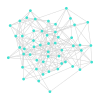

In [4]:
# Visualize the network (if it's not too large)
if nv(graph) <= 200  # Only plot if network is reasonably small
    gplot(graph)
else
    println("Network too large for visualization ($(nv(graph)) nodes)")
    println("Consider using a subset or different visualization approach")
end

## Model Definition

Now we'll set up the epidemic model using the same modular approach as in the other tutorials. The model components are defined in separate source files for modularity and reusability.

In [16]:
include("src/create_graph.jl")

# Agent creation: agents of type Person and properties status, days_infected and risk
@agent struct Person(GraphAgent)
    status::Symbol = :S #((S)usceptible, (I)nfected, (R)ecovered)
    days_infected::Int = 0 # number of days since infection
    risk::Symbol = :high # something to differentiate agents (here, high and low risk)
end

include("src/initialize.jl")
include("src/agent_step.jl")

# Model step: keep track of the infection numbers
function model_step!(model::ABM)
    model.susceptible_count = sum([model[i].status == :S for i in 1:nv(model.graph)])
    model.infected_count = sum([model[i].status == :I for i in 1:nv(model.graph)])
    model.recovered_count = sum([model[i].status == :R for i in 1:nv(model.graph)])
end

model_step! (generic function with 1 method)

## Model Initialization with Edgelist Network

There are two ways to initialize the model with the edgelist network:

### Method 1: Using the `custom_graph` parameter
Pass the pre-loaded graph directly to the initialization function.

### Method 2: Using the `:edgelist` network type
Let the initialization function load the edgelist automatically.

We'll demonstrate both approaches:

In [17]:
# Method 1: Use the custom_graph parameter to pass the pre-loaded graph
model = initialize(
    network_type = :custom,  # Will be set automatically when using custom_graph
    custom_graph = graph,
    patient_zero = :random,
    high_risk = :random,
    fraction_high_risk = 0.1,
    trans_prob = 0.1,
    days_to_recovered = 14,
    seed = 42,
    low_risk_factor = 1.0
)

println("Model initialized with $(model.n_nodes) agents")
println("Network type: $(model.network_type)")
println("Mean degree: $(model.mean_degree)")

Model initialized with 52 agents
Network type: custom
Mean degree: 8


In [18]:
# Alternative Method 2: Use the edgelist network type to load directly
# Uncomment the code below to try this approach instead:

model_alt = initialize(
    network_type = :edgelist,
    edgelist_path = "degs/network",
    patient_zero = :random,
    high_risk = :random,
    fraction_high_risk = 0.1,
    trans_prob = 0.1,
    days_to_recovered = 14,
    seed = 42,
    low_risk_factor = 1.0
)

println("Alternative model initialized with $(model_alt.n_nodes) agents")
println("Network type: $(model_alt.network_type)")
println("Mean degree: $(model_alt.mean_degree)")

Alternative model initialized with 52 agents
Network type: edgelist
Mean degree: 8


## Network Analysis

Now we can analyze the network structure using the regular workflow functions. This includes calculating various network metrics and centrality measures.

In [19]:
include("src/analyze_graph.jl")
include("src/plotting.jl")

# Analyze the graph
println("Analyzing the edgelist network...")
graph_analysis = analyze_graph(model.graph)

println("\n=== Network Summary ===")
display(graph_analysis["summary"])

println("\n=== First few centrality measures ===")
display(first(graph_analysis["centrality"], 10))

Analyzing the edgelist network...

=== Network Summary ===

=== First few centrality measures ===


Row,metric,value
,String,Float64
1,Mean Degree,7.53846
2,Density,0.147813
3,Clustering Coefficient,0.249471
4,Assortativity,-0.0325154
5,Diameter,4.0
6,Number of Connected Components,1.0
7,Max Component Length,52.0


Row,node_id,degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality
,Int64,Float64,Float64,Float64,Float64
1,1,0.137255,0.0234672,0.46789,0.122056
2,2,0.137255,0.023576,0.459459,0.0982098
3,3,0.176471,0.0414607,0.495146,0.143729
4,4,0.156863,0.0320522,0.46789,0.114806
5,5,0.196078,0.0446995,0.476636,0.128021
6,6,0.0784314,0.00537967,0.401575,0.0747681
7,7,0.156863,0.0260105,0.485714,0.160296
8,8,0.254902,0.0724194,0.542553,0.257228
9,9,0.117647,0.0126132,0.451327,0.122553


In [20]:
# Save the analysis to CSV files
CSV.write("data/graph_summary_$(model.network_type)_mdeg_$(model.mean_degree).csv", graph_analysis["summary"])
CSV.write("data/centrality_$(model.network_type)_mdeg_$(model.mean_degree).csv", graph_analysis["centrality"])

println("Analysis results saved to data/ directory")

Analysis results saved to data/ directory


## Epidemic Simulation

Let's run an epidemic simulation on the edgelist network and visualize the dynamics.

In [21]:
# Run a single simulation to test dynamics
println("Running epidemic simulation...")
adata = [:status]
mdata = [:susceptible_count, :infected_count, :recovered_count]
adf, mdf = run!(model, 100; adata, mdata)

println("Simulation completed!")
println("Final outbreak size: $(mdf[end, :recovered_count]) out of $(model.n_nodes) agents")
println("Attack rate: $(round(100 * mdf[end, :recovered_count] / model.n_nodes, digits=1))%")

Running epidemic simulation...
Simulation completed!
Final outbreak size: 52 out of 52 agents
Attack rate: 100.0%


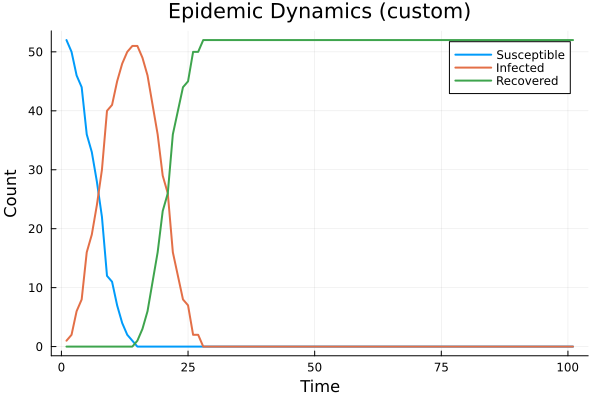

Dynamics plot saved to figures/ directory


In [24]:
# Plot the epidemic dynamics
dynamics_plot = plot_epidemic_trajectories(mdf, model.network_type)
display(dynamics_plot)
savefig(dynamics_plot, "figures/dynamics_$(model.network_type)_mdeg_$(model.mean_degree).pdf")

println("Dynamics plot saved to figures/ directory")

## Network Comparison

One of the advantages of integrating edgelist networks into the regular workflow is the ability to compare them with synthetic network types. Let's compare our edgelist network with random and small-world networks.

In [26]:
# Compare network metrics across different network types
# Use the same number of nodes as the edgelist network for fair comparison
comparison_plot = plot_network_metrics_comparison(
    network_types=[:random, :smallworld, :custom], 
    mean_degree=model.mean_degree, 
    n_nodes=model.n_nodes  # Use actual edgelist network size
)

display(comparison_plot)
println("Network comparison completed with $(model.n_nodes) nodes for all network types!")

Analyzing random network...
Analyzing smallworld network...
Analyzing custom network...

Analyzing smallworld network...
Analyzing custom network...


ErrorException: Custom network type should use the custom_graph parameter in initialize() instead of create_graph()

## Multiple Simulations

For robust analysis, we should run multiple simulations with different random seeds. This helps us understand the variability in epidemic outcomes.

In [13]:
include("src/run_simulations.jl")

# Run multiple simulations (reduced number for demonstration)
println("Running multiple simulations...")

# Create multiple models with different seeds and collect final sizes
final_sizes = []
n_sims = 20  # Adjust this number based on computational resources

for seed in 1:n_sims
    # Create a new model with different seed
    sim_model = initialize(
        custom_graph = graph,
        patient_zero = :random,
        high_risk = :random,
        fraction_high_risk = 0.1,
        trans_prob = 0.1,
        days_to_recovered = 14,
        seed = seed,
        low_risk_factor = 1.0
    )
    
    # Run simulation
    adf_sim, mdf_sim = run!(sim_model, 100; adata=[:status], mdata=[:recovered_count])
    push!(final_sizes, mdf_sim[end, :recovered_count])
    
    if seed % 5 == 0
        println("Completed $seed/$n_sims simulations")
    end
end

println("Multiple simulations completed!")
println("Mean final size: $(round(mean(final_sizes), digits=1))")
println("Standard deviation: $(round(std(final_sizes), digits=1))")

Running multiple simulations...


UndefVarError: UndefVarError: `initialize` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [14]:
# Plot distribution of final outbreak sizes
histogram(final_sizes, 
         bins=15,
         xlabel="Final Outbreak Size",
         ylabel="Frequency",
         title="Distribution of Final Outbreak Sizes\n(Edgelist Network, $n_sims simulations)",
         alpha=0.7,
         color=:steelblue)

# Add vertical line for mean
vline!([mean(final_sizes)], line=(:red, 2, :dash), label="Mean = $(round(mean(final_sizes), digits=1))")

savefig("figures/final_sizes_distribution_$(model.network_type)_mdeg_$(model.mean_degree).pdf")
println("Final sizes distribution plot saved to figures/ directory")

MethodError: MethodError: no method matching zero(::Type{Any})
This error has been manually thrown, explicitly, so the method may exist but be intentionally marked as unimplemented.

Closest candidates are:
  zero(::Type{Union{Missing, T}}) where T
   @ Base missing.jl:105
  zero(!Matched::Type{Union{}}, Any...)
   @ Base number.jl:310
  zero(!Matched::Type{LibGit2.GitHash})
   @ LibGit2 C:\Users\leost\.julia\juliaup\julia-1.11.5+0.x64.w64.mingw32\share\julia\stdlib\v1.11\LibGit2\src\oid.jl:221
  ...


## Summary

This notebook demonstrated how to:

1. **Load networks from edgelist files** and integrate them into the epidemic modeling workflow
2. **Use both methods** for initialization (custom_graph parameter and :edgelist network type)
3. **Analyze network properties** using the same functions as for synthetic networks
4. **Run epidemic simulations** and visualize the dynamics
5. **Compare edgelist networks** with synthetic network types
6. **Perform multiple simulations** to assess variability in outcomes

The integration allows for seamless analysis of real-world network data within the existing framework, enabling researchers to study epidemic dynamics on empirical network structures.

### Key Findings

- **Network Structure**: The loaded network has specific structural properties that differ from synthetic networks
- **Epidemic Dynamics**: The epidemic behavior on the real network may show different patterns compared to random or small-world networks
- **Variability**: Multiple simulations reveal the range of possible outcomes under the same network structure

This approach can be extended to analyze various types of real-world networks and compare how different network structures influence epidemic spread.